In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/Projects/Style-NN

/content/drive/MyDrive/Projects/Style-NN


In [3]:
!pwd

/content/drive/MyDrive/Projects/Style-NN


# Setup

In [4]:
!pip install --upgrade pip
!pip install segmentation-models-pytorch tqdm torch torchvision matplotlib scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 56.6 MB/s  0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 175.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 197.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 41.8 MB/s  0:00:13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 75.2 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 64.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 70.4 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 73.8 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 69.8 MB/s  0:00:02
   ━

In [54]:
import os
import numpy as np
import json

import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torchvision.models import VGG19_Weights
from torchvision.utils import save_image

from PIL import Image
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [181]:
content_file = 'content/landscape.jpg'
style_file = 'styles/klimt.jpg'

# Define preprocessing
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Load content image
content = Image.open(content_file).convert('RGB')

# Apply preprocessing and add batch dimension
input_content = preprocess(content).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# Load style image
style = Image.open(style_file).convert('RGB')

# Apply preprocessing and add batch dimension
input_style = preprocess(style).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# Input Visualization

In [182]:
def show_rgb_tensor(tensor):
    # Remove batch dimension and convert to numpy
    img_np = tensor.squeeze(0).cpu().numpy()  # shape: [3, 224, 224]

    _, axes = plt.subplots(1, 3, figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i, ax in enumerate(axes):
        ax.imshow(img_np[i], cmap='gray')  # img_np[i] is [224, 224]
        ax.set_title(f'{channels[i]} Channel')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

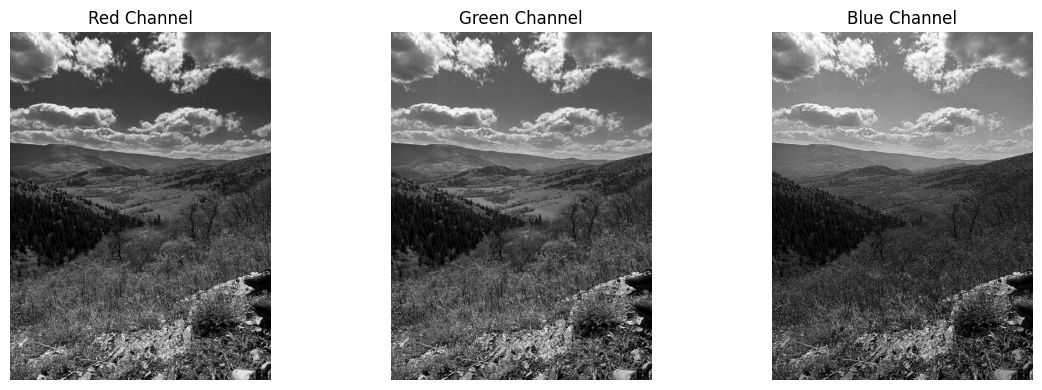

In [183]:
show_rgb_tensor(input_content)

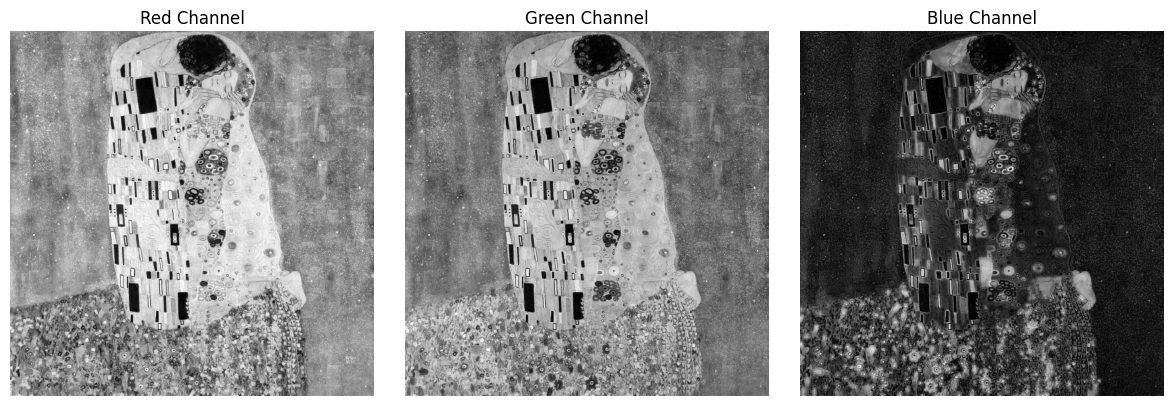

In [184]:
show_rgb_tensor(input_style)

# Get Model

In [185]:
vgg19 = models.vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features

# Set the model to evaluation mode
vgg19.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [186]:
vgg19 = vgg19.to(device)
input_content = input_content.to(device)
input_style = input_style.to(device)

In [187]:
layer_indices = [0, 5, 10, 19, 28]  # Indices of layers to extract features from
layer_names = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

# Content Processing

In [188]:
# Dictionary to store feature maps
feature_maps = {}

# Register hooks to save outputs of selected layers
def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

for idx in layer_indices:
    vgg19[idx].register_forward_hook(get_activation(f'layer_{idx}'))

In [ ]:
with torch.no_grad():
    vgg19(input_content)

In [ ]:
print(f"Feature maps extracted for {len(feature_maps)} layers.")

Feature maps extracted for 5 layers.


In [ ]:
def visualize_feature_maps(feature_maps):
    """Visualize feature maps from the VGG19 model in a single row."""
    n_maps = len(feature_maps)
    fig, axes = plt.subplots(1, n_maps, figsize=(n_maps * 3, 3))
    if n_maps == 1:
        axes = [axes]
    for i, (layer_name, fmap) in enumerate(feature_maps.items()):
        ax = axes[i]
        fmap_img = fmap[0, 0].detach().cpu().numpy()
        ax.imshow(fmap_img, cmap='viridis')
        ax.set_title(f'{layer_name}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

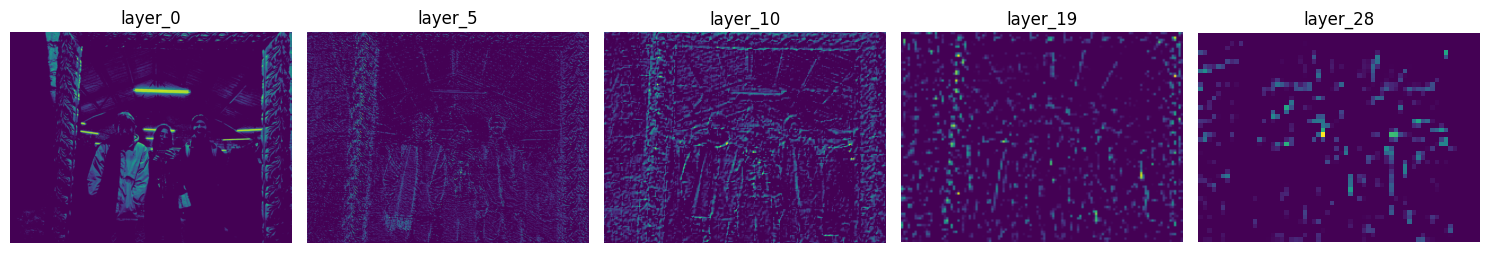

In [ ]:
visualize_feature_maps(feature_maps)

Layer 0 | Step 1/200    
Layer 0 | Step 51/200    
Layer 0 | Step 101/200    
Layer 0 | Step 151/200    
Layer 5 | Step 1/200    
Layer 5 | Step 51/200    
Layer 5 | Step 101/200    
Layer 5 | Step 151/200    
Layer 10 | Step 1/200    
Layer 10 | Step 51/200    
Layer 10 | Step 101/200    
Layer 10 | Step 151/200    
Layer 19 | Step 1/200    
Layer 19 | Step 51/200    
Layer 19 | Step 101/200    
Layer 19 | Step 151/200    
Layer 28 | Step 1/200    
Layer 28 | Step 51/200    
Layer 28 | Step 101/200    
Layer 28 | Step 151/200    


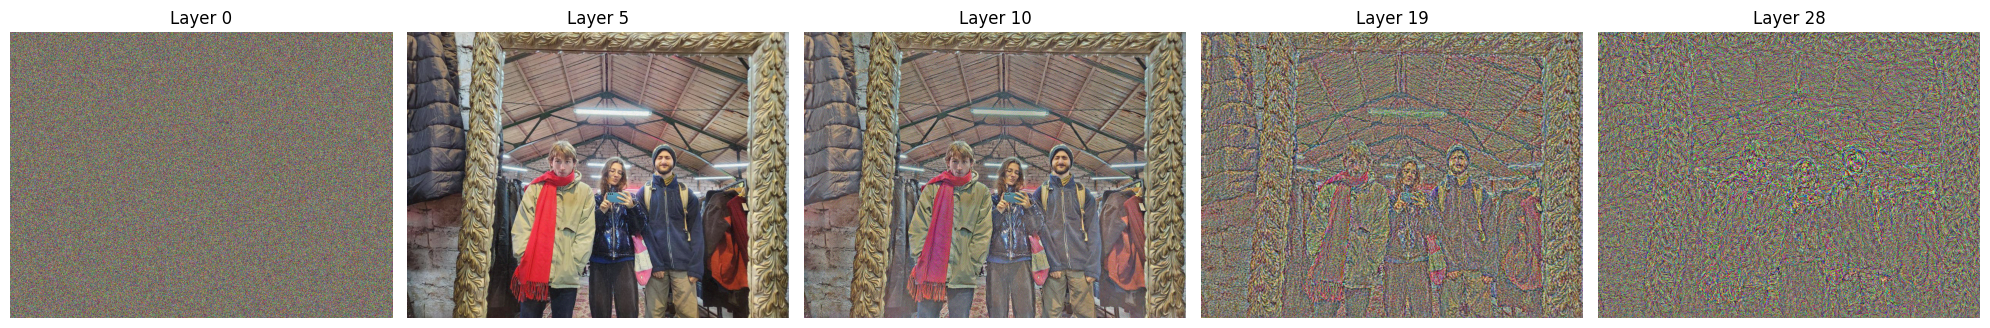

In [ ]:
def get_features(x, model, layer_idx):
    for i, layer in enumerate(model):
        x = layer(x)
        if i == layer_idx:
            return x
    return x

def reconstruct_from_layer(target_features, model, layer_idx, preprocess, num_steps=200, lr=1.0):
    # Start from random noise image
    reconstructed = torch.randn(input_content.shape, requires_grad=True, device=target_features.device)
    optimizer = optim.LBFGS([reconstructed], lr=lr, max_iter=num_steps)
    loss_fn = torch.nn.MSELoss()

    step = [0]
    def closure():
        optimizer.zero_grad()
        features = get_features(reconstructed, model, layer_idx)
        loss = loss_fn(features, target_features)
        loss.backward()
        if step[0] % 50 == 0:
            print(f'Layer {layer_idx} | Step {step[0] + 1}/{num_steps}    ', flush=True)
        step[0] += 1
        return loss

    optimizer.step(closure)

    # Remove normalization for visualization
    img = reconstructed.detach().cpu().squeeze()
    img = img * torch.tensor(preprocess.transforms[1].std).view(3,1,1) + torch.tensor(preprocess.transforms[1].mean).view(3,1,1)
    img = img.clamp(0,1).permute(1,2,0).numpy()
    return img

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, layer_idx in enumerate(layer_indices[:5]):
    with torch.no_grad():
        target_features = get_features(input_content, vgg19, layer_idx)
    reconstructed_img = reconstruct_from_layer(target_features, vgg19, layer_idx, preprocess)
    axes[idx].imshow(reconstructed_img)
    axes[idx].set_title(f'Layer {layer_idx}')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

# Style Processing

In [ ]:
feature_maps = {}

with torch.no_grad():
    vgg19(input_style)

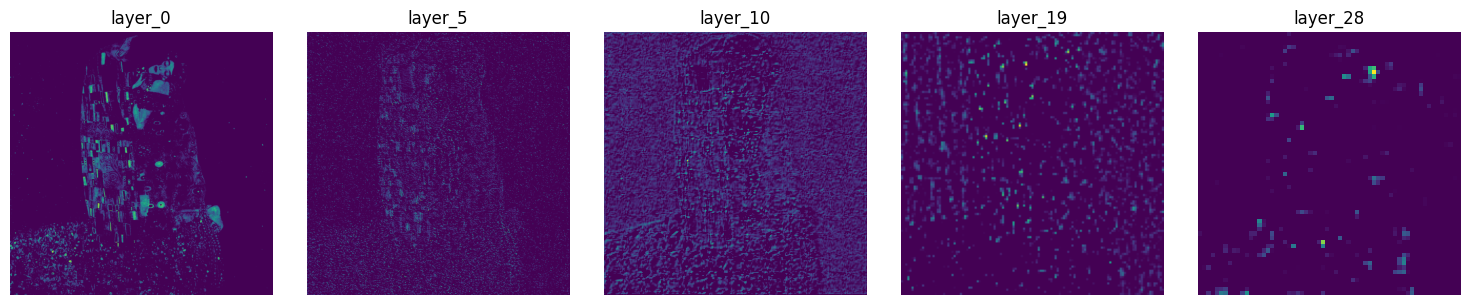

In [ ]:
if feature_maps:
	visualize_feature_maps(feature_maps)
else:
	print("No feature maps to display.")

In [ ]:
def gram_matrix(tensor):
    """Calculate the Gram matrix for a given feature map tensor."""
    # tensor shape: [1, C, H, W]
    b, c, h, w = tensor.size()
    features = tensor.view(c, h * w)
    gram = torch.mm(features, features.t())
    return gram / (c * h * w)

# Calculate Gram matrices for all feature maps
gram_matrices = {layer: gram_matrix(fmap) for layer, fmap in feature_maps.items()}
print(f"Calculated Gram matrices for {len(gram_matrices)} layers.")

Calculated Gram matrices for 5 layers.


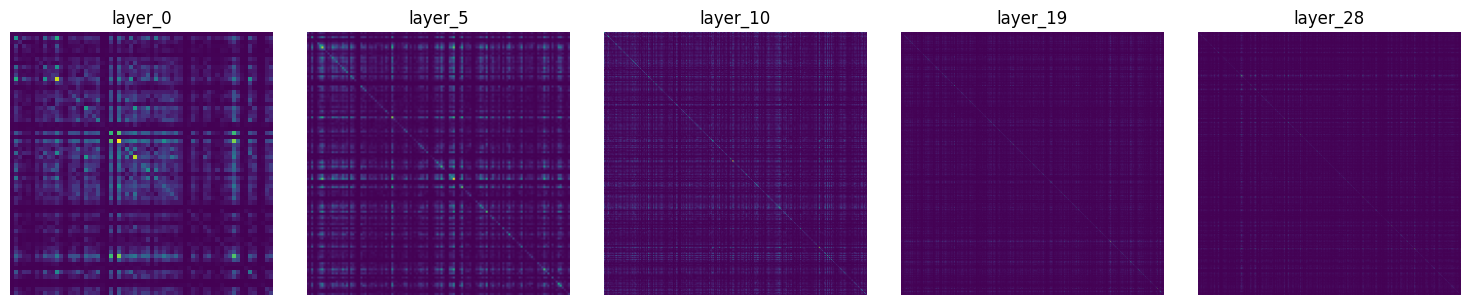

In [ ]:
def visualize_gram_matrices(gram_matrices):
    n_maps = len(gram_matrices)
    if n_maps == 0:
        print("No Gram matrices to display.")
        return
    n_cols = 5
    n_rows = (n_maps + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    for i, (layer_name, gram) in enumerate(gram_matrices.items()):
        ax = axes[i]
        gram_img = gram.detach().cpu().numpy()
        ax.imshow(gram_img, cmap='viridis')
        ax.set_title(f'{layer_name}')
        ax.axis('off')
    # Hide unused axes
    for j in range(i + 1, n_rows * n_cols):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

visualize_gram_matrices(gram_matrices)

In [ ]:
# Layer indices for VGG19: conv1_1=0, conv2_1=5, conv3_1=10, conv4_1=19, conv5_1=28
layer_indices_sets = [
    [0],                # conv1_1
    [0, 5],             # conv1_1, conv2_1
    [0, 5, 10],         # conv1_1, conv2_1, conv3_1
    [0, 5, 10, 19],     # conv1_1, conv2_1, conv3_1, conv4_1
    [0, 5, 10, 19, 28]  # conv1_1, conv2_1, conv3_1, conv4_1, conv5_1
]

def get_features(x, model, layer_indices):
    features = []
    for i, layer in enumerate(model):
        x = layer(x)
        if i in layer_indices:
            features.append(x)
    return features

def style_loss(generated_features, target_grams):
    loss = 0
    for gen_feat, target_gram in zip(generated_features, target_grams):
        gen_gram = gram_matrix(gen_feat)
        loss += torch.nn.functional.mse_loss(gen_gram, target_gram)
    return loss

def reconstruct_from_style_layers(target_grams, model, layer_indices, preprocess, num_steps=300, lr=1.0):
    reconstructed = torch.randn(input_style.shape, requires_grad=True, device=input_style.device)
    optimizer = optim.LBFGS([reconstructed], max_iter=num_steps)
    step = [0]
    def closure():
        optimizer.zero_grad()
        gen_features = get_features(reconstructed, model, layer_indices)
        loss = style_loss(gen_features, target_grams)
        loss.backward()
        if step[0] % 50 == 0:
            print(f'Style Layers {layer_indices} | Step {step[0]+1}/{num_steps}')
        step[0] += 1
        return loss
    optimizer.step(closure)
    img = reconstructed.detach().cpu().squeeze()
    img = img * torch.tensor(preprocess.transforms[1].std).view(3,1,1) + torch.tensor(preprocess.transforms[1].mean).view(3,1,1)
    img = img.clamp(0,1).permute(1,2,0).numpy()
    return img

# Compute target Gram matrices for each subset of layers
fig, axes = plt.subplots(1, len(layer_indices_sets), figsize=(20, 4))
for idx, layer_indices in enumerate(layer_indices_sets):
    with torch.no_grad():
        style_features = get_features(input_style, vgg19, layer_indices)
        target_grams = [gram_matrix(f) for f in style_features]
    reconstructed_img = reconstruct_from_style_layers(target_grams, vgg19, layer_indices, preprocess)
    axes[idx].imshow(reconstructed_img)
    axes[idx].set_title(f"Layers: {', '.join([f'conv{l//5+1}_1' for l in layer_indices])}")
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Combine Content and Style

In [32]:

def content_loss(generated_features, target_features):
    """
    Computes the content loss between generated and target feature maps.
    Args:
        generated_features (torch.Tensor): Feature map from generated image.
        target_features (torch.Tensor): Feature map from content image.
    Returns:
        torch.Tensor: Content loss value.
    """
    return F.mse_loss(generated_features, target_features)

def gram_matrix(tensor):
    """
    Computes the Gram matrix for a given feature map tensor.
    Args:
        tensor (torch.Tensor): Feature map of shape [1, C, H, W].
    Returns:
        torch.Tensor: Gram matrix of shape [C, C].
    """
    b, c, h, w = tensor.size()
    features = tensor.view(c, h * w)
    gram = torch.mm(features, features.t())
    return gram / (c * h * w)

def style_loss(generated_features, target_grams):
    """
    Computes the style loss between generated and target Gram matrices.
    Args:
        generated_features (list of torch.Tensor): Feature maps from generated image.
        target_grams (list of torch.Tensor): Gram matrices from style image.
    Returns:
        torch.Tensor: Style loss value.
    """
    loss = 0
    for gen_feat, target_gram in zip(generated_features, target_grams):
        gen_gram = gram_matrix(gen_feat)
        loss += F.mse_loss(gen_gram, target_gram)
    return loss

## Config

In [201]:
# Choose layers for content and style
content_layer_idx = 10  # conv4_1
style_layer_indices = [0, 5, 10, 19, 28]  # conv1_1, conv2_1, conv3_1, conv4_1

# Extract target features and target Gram matrices
with torch.no_grad():
    target_content_features = None
    x = input_content
    for i, layer in enumerate(vgg19):
        x = layer(x)
        if i == content_layer_idx:
            target_content_features = x
            break

with torch.no_grad():
    style_features = []
    x = input_style
    for i, layer in enumerate(vgg19):
        x = layer(x)
        if i in style_layer_indices:
            style_features.append(x)
    target_style_grams = [gram_matrix(f) for f in style_features]

In [202]:
# Set weights for losses
alpha = 1e0  # content weight
beta = 5e5   # style weight

num_steps = 300

## LBFGS

Step 50/300 | Content Loss: 49.4715 | Style Loss: 0.0000
Step 100/300 | Content Loss: 46.1388 | Style Loss: 0.0000
Step 150/300 | Content Loss: 45.3408 | Style Loss: 0.0000
Step 200/300 | Content Loss: 44.9893 | Style Loss: 0.0000
Step 250/300 | Content Loss: 44.8152 | Style Loss: 0.0000
Step 300/300 | Content Loss: 44.7129 | Style Loss: 0.0000


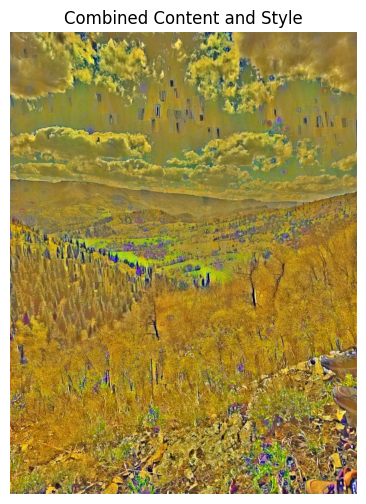

In [203]:
# Initialize generated image as random noise
generated = torch.randn(input_content.shape, requires_grad=True, device=device)
step = [0]
optimizer = optim.LBFGS([generated], lr=1.0, max_iter=num_steps)

def closure():
    optimizer.zero_grad()
    gen_content_features = None
    gen_style_features = []
    x = generated
    for i, layer in enumerate(vgg19):
        x = layer(x)
        if i == content_layer_idx:
            gen_content_features = x
        if i in style_layer_indices:
            gen_style_features.append(x)
    c_loss = content_loss(gen_content_features, target_content_features)
    s_loss = style_loss(gen_style_features, target_style_grams)
    loss = alpha * c_loss + beta * s_loss
    loss.backward()
    if (step[0] + 1) % 50 == 0:
        print(f"Step {step[0]+1}/{num_steps} | Content Loss: {c_loss.item():.4f} | Style Loss: {s_loss.item():.4f}")
    step[0] += 1
    return loss

optimizer.step(closure)

# De-normalize and visualize result
result_img = generated.detach().cpu().squeeze()
result_img = result_img * torch.tensor(preprocess.transforms[1].std).view(3,1,1) + torch.tensor(preprocess.transforms[1].mean).view(3,1,1)
result_img = result_img.clamp(0,1).permute(1,2,0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(result_img)
plt.title("Combined Content and Style")
plt.axis('off')
plt.show()

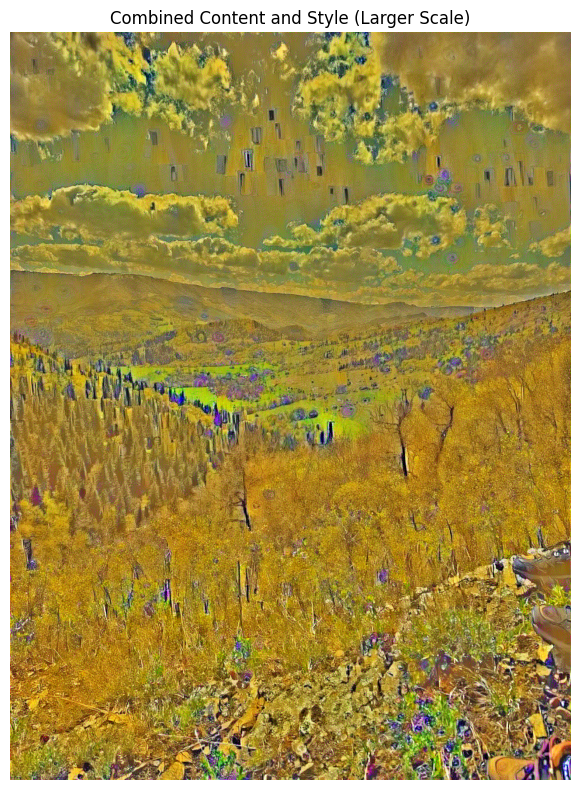

In [204]:
plt.figure(figsize=(8, 8))
plt.imshow(result_img)
plt.title("Combined Content and Style (Larger Scale)")
plt.axis('off')
plt.tight_layout()
plt.show()

## Adam

Step 50/100 | Content Loss: 9.8387 | Style Loss: 0.0001
Step 100/100 | Content Loss: 7.4044 | Style Loss: 0.0000


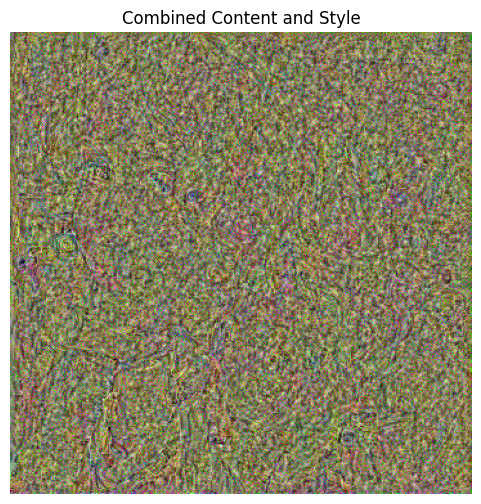

In [79]:
# Initialize generated image as random noise
generated = torch.randn(input_content.shape, requires_grad=True, device=device)
optimizer = optim.Adam([generated], lr=0.1)

for _ in range(num_steps):
    optimizer.zero_grad()
    gen_content_features = None
    gen_style_features = []
    x = generated
    for i, layer in enumerate(vgg19):
        x = layer(x)
        if i == content_layer_idx:
            gen_content_features = x
        if i in style_layer_indices:
            gen_style_features.append(x)
    c_loss = content_loss(gen_content_features, target_content_features)
    s_loss = style_loss(gen_style_features, target_style_grams)
    loss = alpha * c_loss + beta * s_loss
    loss.backward()
    optimizer.step()
    if (_ + 1) % 50 == 0:
        print(f"Step {_+1}/{num_steps} | Content Loss: {c_loss.item():.4f} | Style Loss: {s_loss.item():.4f}")

# De-normalize and visualize result
result_img = generated.detach().cpu().squeeze()
result_img = result_img * torch.tensor(preprocess.transforms[1].std).view(3,1,1) + torch.tensor(preprocess.transforms[1].mean).view(3,1,1)
result_img = result_img.clamp(0,1).permute(1,2,0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(result_img)
plt.title("Combined Content and Style")
plt.axis('off')
plt.show()


## Save Image

In [205]:
result_tensor = torch.from_numpy(result_img).permute(2, 0, 1)

# Save the image
result_name = 'landscape_klimt'
os.mkdir(f'result/{result_name}')
try:
  with open(f'result/{result_name}/config.json', 'w') as f:
    json.dump({
        'alpha': alpha,
        'beta': beta,
        'num_steps': num_steps,
        'content_layer_idx': content_layer_idx,
        'style_layer_indices': style_layer_indices,
        'update_rule': 'LBFGS'
        }, f, indent=4)
except IOError as e:
  print(f"An error occurred: {e}")
save_image(result_tensor, f'result/{result_name}/{result_name}.png')